<a href="https://colab.research.google.com/github/NauffalEl/banyumas-school-geospatial-tsp/blob/main/SA_MODELING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#INSTALL

In [ ]:
!pip install scikit-learn pandas --quiet

In [ ]:
!pip install -U gdown --quiet

#IMPORT LIBRARY

In [ ]:
import pandas as pd
import gdown
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

#SOURCE CODE

In [ ]:
folder_url = "https://drive.google.com/drive/folders/1sC53qOcdIMVweRtonXo-FGgiiI-XauOX?usp=sharing"
gdown.download_folder(folder_url, quiet=False, use_cookies=False)

Retrieving folder contents


Retrieving folder 1Uyq9EXjmQnhAJ91m2GbdIbetAI7rID6j test
Processing file 1PqjUWaoNz8JkfiZesYCTAgEhQSZqJEmM yogyakarta_daerah_istimewa_yogyakarta_indonesia_FIX DATASET.csv
Retrieving folder 1TV9UngCUZrcB9410xSUJsETR4s_xc9wH train dan val
Processing file 1HPII3HWT3PrZm-7GlkCo2eVc4dvjfYJn kabupaten_bantul_daerah_istimewa_yogyakarta_indonesia_FIX DATASET.csv
Processing file 1FU4xjR2YyXlIamoECoAeZK5IcuiURN9F sleman_daerah_istimewa_yogyakarta_indonesia_FIX DATASET.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1PqjUWaoNz8JkfiZesYCTAgEhQSZqJEmM
To: /content/TUGAS BESAR STRATEGI ALGORITMA/test/yogyakarta_daerah_istimewa_yogyakarta_indonesia_FIX DATASET.csv
100%|██████████| 31.3k/31.3k [00:00<00:00, 40.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1HPII3HWT3PrZm-7GlkCo2eVc4dvjfYJn
To: /content/TUGAS BESAR STRATEGI ALGORITMA/train dan val/kabupaten_bantul_daerah_istimewa_yogyakarta_indonesia_FIX DATASET.csv
100%|██████████| 47.3k/47.3k [00:00<00:00, 54.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1FU4xjR2YyXlIamoECoAeZK5IcuiURN9F
To: /content/TUGAS BESAR STRATEGI ALGORITMA/train dan val/sleman_daerah_istimewa_yogyakarta_indonesia_FIX DATASET.csv
100%|██████████| 52.3k/52.3k [00:00<00:00, 60.7MB/s]
Download completed


['/content/TUGAS BESAR STRATEGI ALGORITMA/test/yogyakarta_daerah_istimewa_yogyakarta_indonesia_FIX DATASET.csv',
 '/content/TUGAS BESAR STRATEGI ALGORITMA/train dan val/kabupaten_bantul_daerah_istimewa_yogyakarta_indonesia_FIX DATASET.csv',
 '/content/TUGAS BESAR STRATEGI ALGORITMA/train dan val/sleman_daerah_istimewa_yogyakarta_indonesia_FIX DATASET.csv']

In [ ]:
df_sleman = pd.read_csv('/content/TUGAS BESAR STRATEGI ALGORITMA/train dan val/sleman_daerah_istimewa_yogyakarta_indonesia_FIX DATASET.csv')
df_bantul = pd.read_csv('/content/TUGAS BESAR STRATEGI ALGORITMA/train dan val/kabupaten_bantul_daerah_istimewa_yogyakarta_indonesia_FIX DATASET.csv')
df_yogyakarta = pd.read_csv('/content/TUGAS BESAR STRATEGI ALGORITMA/test/yogyakarta_daerah_istimewa_yogyakarta_indonesia_FIX DATASET.csv')

In [ ]:
features = [
    'Kepadatan Jalan (km jalan/km²)',
    'Persentase Area Hijau (%)',
    'Kepadatan Bangunan (jumlah/km²)'
]
target = 'Kategori Emisi Karbon'

In [ ]:
datasets = {
    'Sleman': df_sleman,
    'Yogyakarta': df_yogyakarta,
    'Kabupaten Bantul': df_bantul
}

In [ ]:
#TAMPIL DATA
sleman_counts = df_sleman['Kategori Emisi Karbon'].value_counts()
bantul_counts = df_bantul['Kategori Emisi Karbon'].value_counts()
yogyakarta_counts = df_yogyakarta['Kategori Emisi Karbon'].value_counts()

rekap_df = pd.DataFrame({
    'Sleman (Train/Val)': sleman_counts,
    'Bantul (Train/Val)': bantul_counts,
    'Yogyakarta (Test)': yogyakarta_counts
}).T.fillna(0).astype(int)

rekap_df = rekap_df[['Parah (Tinggi)', 'Sedang', 'Normal (Rendah)']]

print("=== Rekapitulasi Kategori Emisi Karbon ===\n")
display(rekap_df)


=== Rekapitulasi Kategori Emisi Karbon ===



Kategori Emisi Karbon,Parah (Tinggi),Sedang,Normal (Rendah)
Sleman (Train/Val),115,166,149
Bantul (Train/Val),122,137,126
Yogyakarta (Test),104,69,77


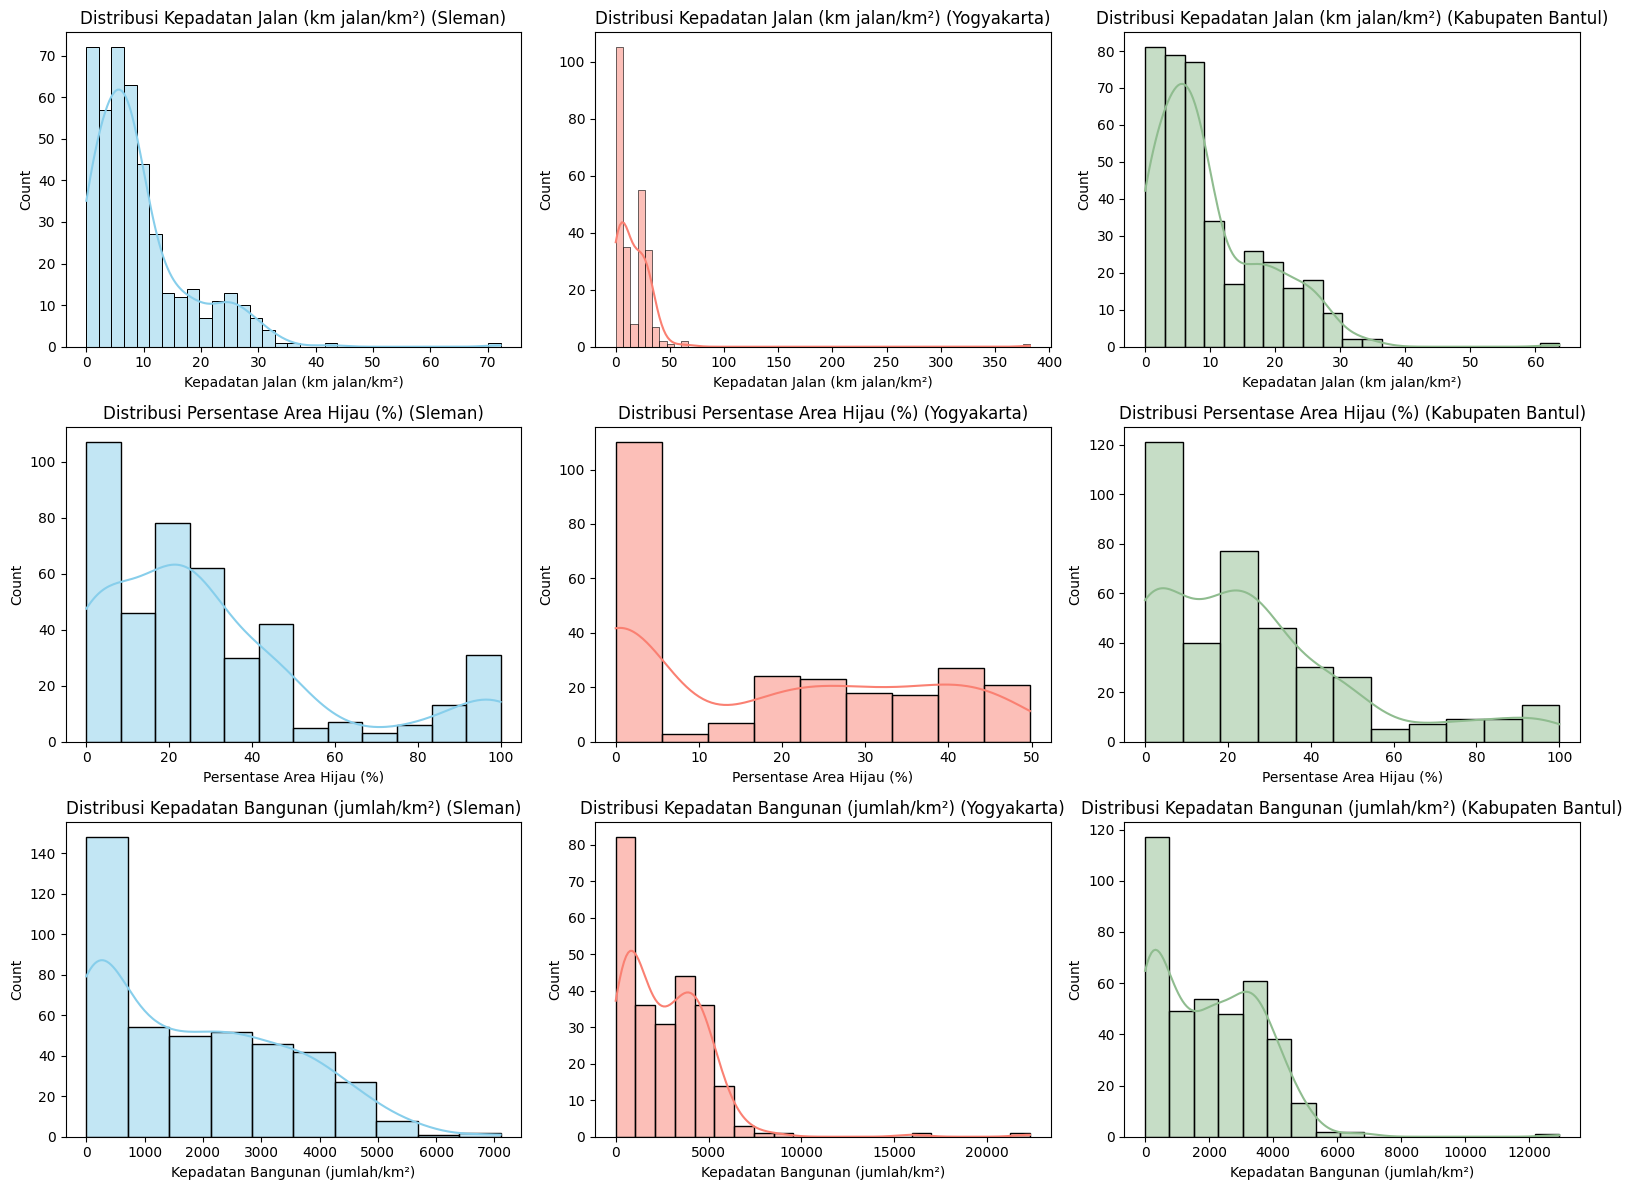

In [ ]:
plt.figure(figsize=(16, 12))

for i, feature in enumerate(features):
    plt.subplot(len(features), 3, i*3+1)
    sns.histplot(datasets['Sleman'][feature], kde=True, color='skyblue')
    plt.title(f'Distribusi {feature} (Sleman)')

    plt.subplot(len(features), 3, i*3+2)
    sns.histplot(datasets['Yogyakarta'][feature], kde=True, color='salmon')
    plt.title(f'Distribusi {feature} (Yogyakarta)')

    plt.subplot(len(features), 3, i*3+3)
    sns.histplot(datasets['Kabupaten Bantul'][feature], kde=True, color='#8FBC8F')
    plt.title(f'Distribusi {feature} (Kabupaten Bantul)')

plt.tight_layout()
plt.show()

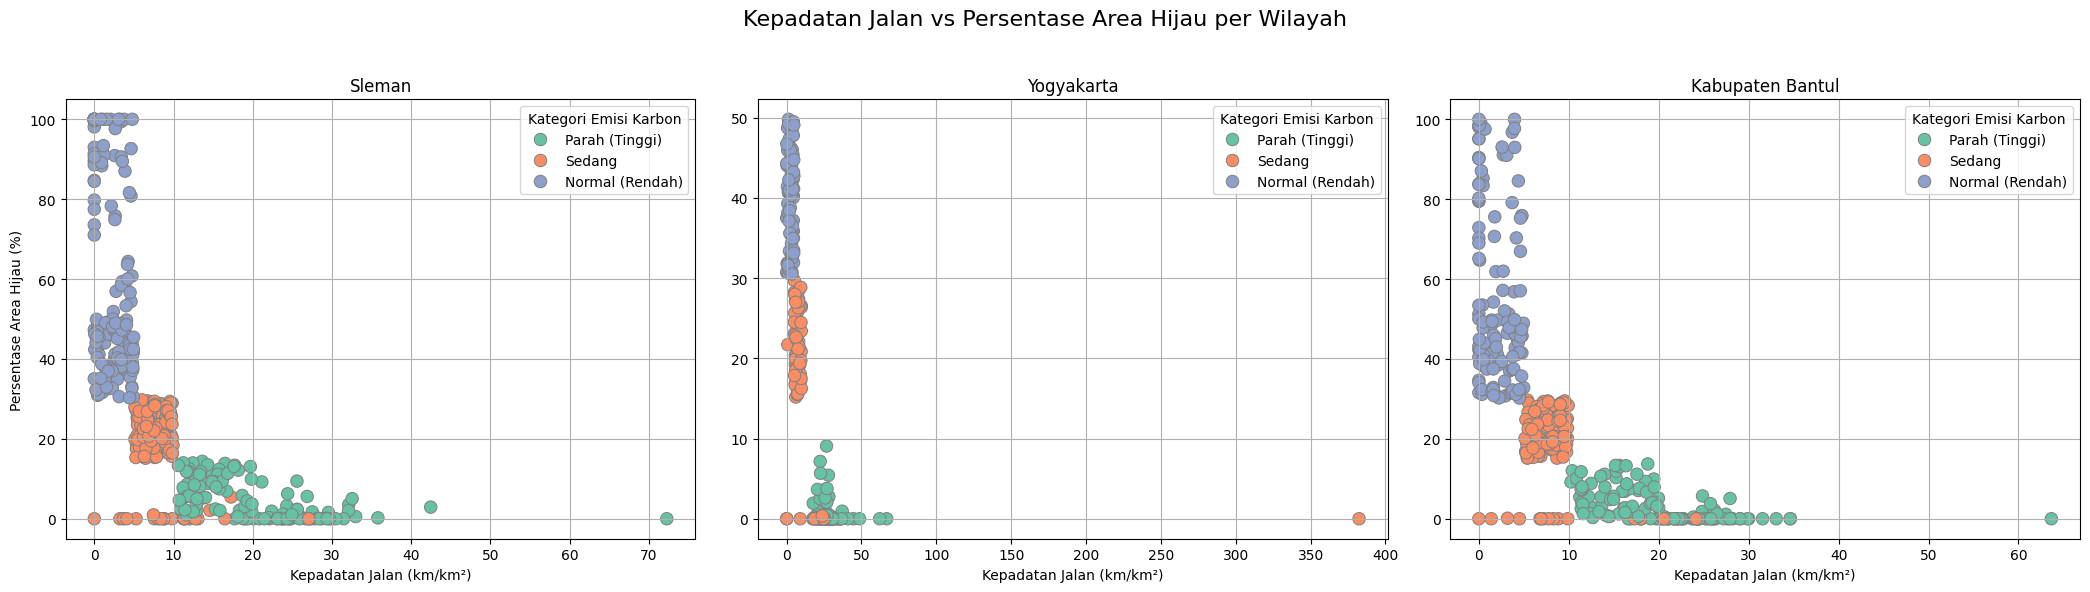

In [ ]:
plt.figure(figsize=(21, 6))

#Sleman
plt.subplot(1, 3, 1)
sns.scatterplot(
    data=datasets['Sleman'],
    x='Kepadatan Jalan (km jalan/km²)',
    y='Persentase Area Hijau (%)',
    hue=target,
    palette='Set2',
    edgecolor='gray',
    s=80
)
plt.title('Sleman')
plt.xlabel('Kepadatan Jalan (km/km²)')
plt.ylabel('Persentase Area Hijau (%)')
plt.grid(True)

#Yogyakarta
plt.subplot(1, 3, 2)
sns.scatterplot(
    data=datasets['Yogyakarta'],
    x='Kepadatan Jalan (km jalan/km²)',
    y='Persentase Area Hijau (%)',
    hue=target,
    palette='Set2',
    edgecolor='gray',
    s=80
)
plt.title('Yogyakarta')
plt.xlabel('Kepadatan Jalan (km/km²)')
plt.ylabel('')
plt.grid(True)

#Kabupaten Bantul
plt.subplot(1, 3, 3)
sns.scatterplot(
    data=datasets['Kabupaten Bantul'],
    x='Kepadatan Jalan (km jalan/km²)',
    y='Persentase Area Hijau (%)',
    hue=target,
    palette='Set2',
    edgecolor='gray',
    s=80
)
plt.title('Kabupaten Bantul')
plt.xlabel('Kepadatan Jalan (km/km²)')
plt.ylabel('')
plt.grid(True)

plt.suptitle('Kepadatan Jalan vs Persentase Area Hijau per Wilayah', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
#GABUNG DATA
df_train_raw = pd.concat([df_sleman, df_bantul], ignore_index=True)

In [ ]:
for col in features:
    lower = df_train_raw[col].quantile(0.01)
    upper = df_train_raw[col].quantile(0.99)
    df_train_raw[col] = df_train_raw[col].clip(lower, upper)

In [ ]:
X_train_val = df_train_raw[features]
y_train_val = df_train_raw[target]

X_test = df_yogyakarta[features]
y_test = df_yogyakarta[target]

In [ ]:
le = LabelEncoder()
y_train_val_enc = le.fit_transform(y_train_val)
y_test_enc = le.transform(y_test)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val_enc, test_size=0.2, random_state=42, stratify=y_train_val_enc)

print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 652
Validation size: 163
Test size: 250


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

##== RANDOM FOREST ==

In [ ]:
print("\n=== RANDOM FOREST ===")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)


=== RANDOM FOREST ===


RandomForestClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, random_state=42)

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5)
print(f"Cross-Validation Accuracy (mean): {scores.mean():.4f}")
print(f"All scores: {scores}")

Cross-Validation Accuracy (mean): 1.0000
All scores: [1. 1. 1. 1. 1.]


In [ ]:
y_val_pred = rf_model.predict(X_val_scaled)
val_acc = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy RF: {val_acc:.4f}")

Validation Accuracy RF: 1.0000


In [ ]:
y_rf_pred = rf_model.predict(X_test_scaled)
acc_rf = accuracy_score(y_test_enc, y_rf_pred)
print(f"Test Accuracy RF: {acc_rf:.4f}")
print("Classification Report RF:")
print(classification_report(y_test_enc, y_rf_pred, target_names=le.classes_))

Test Accuracy RF: 0.9920
Classification Report RF:
                 precision    recall  f1-score   support

Normal (Rendah)       1.00      1.00      1.00        77
 Parah (Tinggi)       0.98      1.00      0.99       104
         Sedang       1.00      0.97      0.99        69

       accuracy                           0.99       250
      macro avg       0.99      0.99      0.99       250
   weighted avg       0.99      0.99      0.99       250



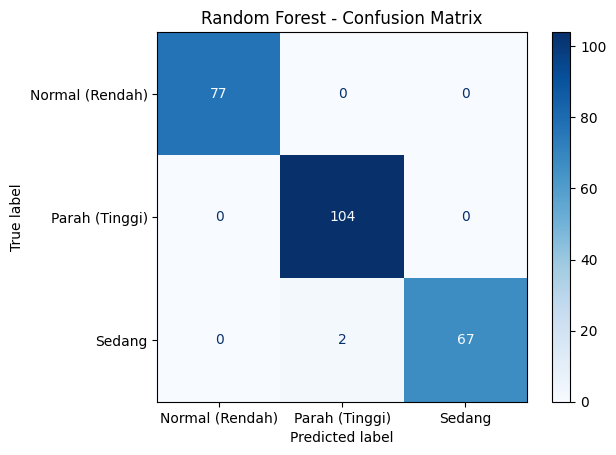

In [ ]:
cm_rf = confusion_matrix(y_test_enc, y_rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le.classes_)
disp_rf.plot(cmap=plt.cm.Blues)
plt.title("Random Forest - Confusion Matrix")
plt.grid(False)
plt.show()


##== XGBOOST ==

In [ ]:
print("\n=== XGBOOST ===")
xgb_model = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)


=== XGBOOST ===


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=3, num_parallel_tree=None, ...)

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb_model, X_train_scaled, y_train, cv=5)
print(f"Cross-Validation Accuracy (mean): {scores.mean():.4f}")
print(f"All scores: {scores}")

Cross-Validation Accuracy (mean): 0.9969
All scores: [0.99236641 1.         0.99230769 1.         1.        ]


In [ ]:
y_val_pred = xgb_model.predict(X_val_scaled)
val_acc = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy XGB: {val_acc:.4f}")

Validation Accuracy XGB: 1.0000


In [ ]:
y_xgb_pred = xgb_model.predict(X_test_scaled)
acc_xgb = accuracy_score(y_test_enc, y_xgb_pred)
print(f"Test Accuracy XGB: {acc_xgb:.4f}")
print("Classification Report XGB:")
print(classification_report(y_test_enc, y_xgb_pred, target_names=le.classes_))

Test Accuracy XGB: 0.9920
Classification Report XGB:
                 precision    recall  f1-score   support

Normal (Rendah)       1.00      1.00      1.00        77
 Parah (Tinggi)       0.98      1.00      0.99       104
         Sedang       1.00      0.97      0.99        69

       accuracy                           0.99       250
      macro avg       0.99      0.99      0.99       250
   weighted avg       0.99      0.99      0.99       250



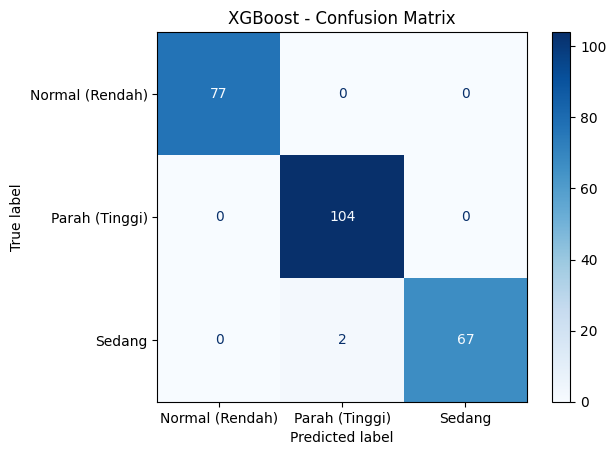

In [ ]:
cm_xgb = confusion_matrix(y_test_enc, y_xgb_pred)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=le.classes_)
disp_xgb.plot(cmap=plt.cm.Blues)
plt.title("XGBoost - Confusion Matrix")
plt.grid(False)
plt.show()

## TRY MODEL

In [ ]:
# Inputan
sample = np.array([[8, 700, 1000]])  #[Kepadatan Jalan, Persentase RTH, Kepadatan Bangunan]
sample_scaled = scaler.transform(sample)

pred_rf = rf_model.predict(sample_scaled)
pred_xgb = xgb_model.predict(sample_scaled)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
print("\nPrediksi Emisi Karbon untuk sampel:")
print(f"Random Forest: {le.inverse_transform(pred_rf)[0]}")
print(f"XGBoost      : {le.inverse_transform(pred_xgb)[0]}")


Prediksi Emisi Karbon untuk sampel:
Random Forest: Normal (Rendah)
XGBoost      : Normal (Rendah)
